In [1]:
#Part 1 - Data Preparation 

#Import the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
#pip install scikit-learn
from sklearn.cluster import KMeans
#!pip install fg-data-profiling
import data_profiling
from data_profiling import ProfileReport
from sklearn.metrics import silhouette_score

In [2]:
path='Online Retail.xlsx'

In [3]:
df=pd.read_excel(path)


In [4]:
df.shape

(541909, 8)

##Data Cleaning

In [5]:
#Handling the missing values here 

#Finding how many nulls are here
print(df.isnull().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [6]:
#Since stockcode shows the description of the product, Fill the missing description with the values from stockcode.
df['Description']=df['Description'].fillna(df['StockCode'])

In [7]:
df['CustomerID'].notnull().value_counts()

CustomerID
True     406829
False    135080
Name: count, dtype: int64

In [8]:
#Drop the null customer ID
df = df[pd.notnull(df['CustomerID'])]

In [9]:
df.shape

(406829, 8)

In [10]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  object        
 1   StockCode    406829 non-null  object        
 2   Description  406829 non-null  object        
 3   Quantity     406829 non-null  int64         
 4   InvoiceDate  406829 non-null  datetime64[ns]
 5   UnitPrice    406829 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      406829 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 27.9+ MB
None


In [11]:
#Here we change the data types of the InvoiceNo, StockCode, Description, and Country
df = df.astype({'InvoiceNo':'string','StockCode': 'string', 'Description': 'string'})
df['Country']=pd.Categorical(df['Country'])

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  string        
 1   StockCode    406829 non-null  string        
 2   Description  406829 non-null  string        
 3   Quantity     406829 non-null  int64         
 4   InvoiceDate  406829 non-null  datetime64[ns]
 5   UnitPrice    406829 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      406829 non-null  category      
dtypes: category(1), datetime64[ns](1), float64(2), int64(1), string(3)
memory usage: 25.2 MB


In [13]:
#Removing the cancelled transcations

# Create a mask for cancelled transactions
cancelled_transaction = df['InvoiceNo'].str.startswith('C')

num_cancelled = cancelled_transaction.sum()
print(f"Cancelled transactions: {num_cancelled}")

Cancelled transactions: 8905


In [14]:
df=df[~df['InvoiceNo'].str.startswith('C')]

In [15]:
df['InvoiceNo'].str.startswith('C').value_counts()

InvoiceNo
False    397924
Name: count, dtype: Int64

In [16]:
#Here We find out what are the abnormal Quantity and Unit Price.
#df.loc[df['Quantity']<=0]

In [17]:
#df.loc[df['UnitPrice']<=0]

In [18]:
#Remove the invalid quantity and unit price

df=df.loc[df['Quantity']>0]
df=df.loc[df['UnitPrice']>0]

In [19]:
df.shape

(397884, 8)

In [20]:
#To make sure the time format is correct

df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])

In [21]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  string        
 1   StockCode    397884 non-null  string        
 2   Description  397884 non-null  string        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      397884 non-null  category      
dtypes: category(1), datetime64[ns](1), float64(2), int64(1), string(3)
memory usage: 24.7 MB
None


In [22]:
#Removing the December 2011 since it is incomplete .
#The data of 2011 December ends on 9th December 2011.

print('Date Range: %s ~ %s' % (df['InvoiceDate'].min(), df['InvoiceDate'].max()))
df.loc[df['InvoiceDate']>='2011-12-01']

Date Range: 2010-12-01 08:26:00 ~ 2011-12-09 12:50:00


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
516403,579899,23301,GARDENERS KNEELING PAD KEEP CALM,24,2011-12-01 08:33:00,1.65,15687.0,United Kingdom
516404,579899,22623,BOX OF VINTAGE JIGSAW BLOCKS,3,2011-12-01 08:33:00,5.95,15687.0,United Kingdom
516405,579899,20970,PINK FLORAL FELTCRAFT SHOULDER BAG,4,2011-12-01 08:33:00,3.75,15687.0,United Kingdom
516406,579899,23562,SET OF 6 RIBBONS PERFECTLY PRETTY,6,2011-12-01 08:33:00,2.89,15687.0,United Kingdom
516407,579899,71477,COLOURED GLASS STAR T-LIGHT HOLDER,4,2011-12-01 08:33:00,3.95,15687.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France


In [23]:
#Filter the date which are earlier than December 2011
df=df.loc[df['InvoiceDate']<'2011-12-01']

In [24]:
df.shape

(380580, 8)

In [25]:
#Findiing out if there duplicated rows


In [26]:
#Removing the duplicated rows
df=df.drop_duplicates()

In [27]:

df.duplicated().sum()

np.int64(0)

In [28]:
#Part - 2
##Exploratory Data Analysis

In [29]:
oder_detail_profile = ProfileReport(df, title="Order Detail Profiling Report")

In [30]:
oder_detail_profile.to_file("order_detail_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:01<00:00,  4.12it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [31]:
#Part - 3

##Customer Segmentation

In [32]:
#Makeing a new column for the total price
df['TotalSale']=df['Quantity']*df['UnitPrice']

In [33]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSale
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [34]:
#Sales Distribution per customer
customer_df=df.groupby(by='CustomerID').agg({'TotalSale':'sum',
                                            'InvoiceNo':'nunique'})

In [35]:
customer_df.columns = ['TotalSales', 'OrderCount']

In [36]:
#Average Order Value 
customer_df['Average_Order_Value'] = customer_df['TotalSales']/customer_df['OrderCount']
customer_df

,TotalSales,OrderCount,Average_Order_Value
CustomerID,,,
12346.0,77183.60,1,77183.600000
12347.0,4085.18,6,680.863333
12348.0,1797.24,4,449.310000
12349.0,1757.55,1,1757.550000
12350.0,334.40,1,334.400000
...,...,...,...
18280.0,180.60,1,180.600000
18281.0,80.82,1,80.820000
18282.0,100.21,1,100.210000


In [37]:
customer_df.describe()

,TotalSales,OrderCount,Average_Order_Value
count,4297.000000,4297.000000,4297.000000
mean,1947.874902,4.131720,398.839860
std,8351.696003,7.412705,1271.279788
min,2.900000,1.000000,2.900000
25%,303.160000,1.000000,177.873333
50%,650.750000,2.000000,293.445000
75%,1594.230000,4.000000,428.930000
max,268478.000000,200.000000,77183.600000


In [38]:
#Ranking the data
ranked_df=customer_df.rank(method='first')

In [39]:
ranked_df
ranked_df.describe()

,TotalSales,OrderCount,Average_Order_Value
count,4297.000000,4297.000000,4297.000000
mean,2149.000000,2149.000000,2149.000000
std,1240.581383,1240.581383,1240.581383
min,1.000000,1.000000,1.000000
25%,1075.000000,1075.000000,1075.000000
50%,2149.000000,2149.000000,2149.000000
75%,3223.000000,3223.000000,3223.000000
max,4297.000000,4297.000000,4297.000000


In [40]:
#normalizing the data
normalized_df= (ranked_df - ranked_df.mean())/ranked_df.std()

In [41]:
normalized_df.head()
normalized_df.describe()

,TotalSales,OrderCount,Average_Order_Value
count,4.297000e+03,4297.000000,4.297000e+03
mean,6.614315e-18,0.000000,6.614315e-18
std,1.000000e+00,1.000000,1.000000e+00
min,-1.731446e+00,-1.731446,-1.731446e+00
25%,-8.657231e-01,-0.865723,-8.657231e-01
50%,0.000000e+00,0.000000,0.000000e+00
75%,8.657231e-01,0.865723,8.657231e-01
max,1.731446e+00,1.731446,1.731446e+00


In [42]:
#Finding how many cluster is suitable

for n_cluster in [2,3,4,5,6,7,8]:
    kmeans = KMeans(n_clusters=n_cluster).fit(
        normalized_df[['TotalSales', 'OrderCount', 'Average_Order_Value']]
    )
    silhouette_avg = silhouette_score(
        normalized_df[['TotalSales', 'OrderCount', 'Average_Order_Value']],
        kmeans.labels_
    )

    print('Silhouette Score for %i Clusters: %0.4f' % (n_cluster, silhouette_avg))

#the suitable cluster is 4.

Silhouette Score for 2 Clusters: 0.4288
Silhouette Score for 3 Clusters: 0.4133
Silhouette Score for 4 Clusters: 0.4121
Silhouette Score for 5 Clusters: 0.3837
Silhouette Score for 6 Clusters: 0.3791
Silhouette Score for 7 Clusters: 0.3906
Silhouette Score for 8 Clusters: 0.3807


In [43]:
kmeans=KMeans(n_clusters=4).fit(
    normalized_df[['TotalSales','OrderCount','Average_Order_Value']]
)

In [44]:
clustered_df=normalized_df.copy(deep=True)
clustered_df['Cluster']=kmeans.labels_

In [45]:
clustered_df.head(20)

,TotalSales,OrderCount,Average_Order_Value,Cluster
CustomerID,,,,
12346.0,1.724998,-1.731446,1.731446,3
12347.0,1.460606,1.064017,1.404180,0
12348.0,0.968094,0.573118,0.933433,0
12349.0,0.949555,-1.730640,1.683888,3
12350.0,-0.723048,-1.729834,0.341775,3
12352.0,1.194601,1.309064,0.178948,0
12353.0,-1.637136,-1.729028,-1.570232,1
12354.0,0.513469,-1.728222,1.612953,3
12355.0,-0.382885,-1.727416,0.975349,3


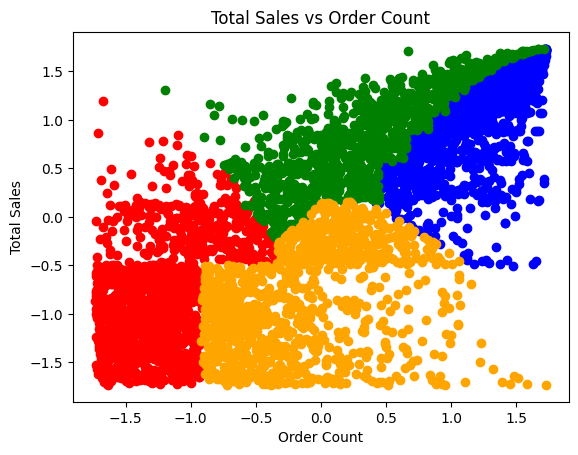

In [46]:
#Data Virtualization 

#TotalSales vs Order Counts

%matplotlib inline 

plt.scatter(
    clustered_df.loc[clustered_df['Cluster'] == 0]['TotalSales'],
    clustered_df.loc[clustered_df['Cluster'] == 0]['OrderCount'],
    c='blue'
)

plt.scatter(
    clustered_df.loc[clustered_df['Cluster'] == 1]['TotalSales'],
    clustered_df.loc[clustered_df['Cluster'] == 1]['OrderCount'],
    c='red'
)

plt.scatter(
    clustered_df.loc[clustered_df['Cluster'] == 2]['TotalSales'],
    clustered_df.loc[clustered_df['Cluster'] == 2]['OrderCount'],
    c='green'
)

plt.scatter(
    clustered_df.loc[clustered_df['Cluster'] == 3]['TotalSales'],
    clustered_df.loc[clustered_df['Cluster'] == 3]['OrderCount'],
    c='orange'
)



plt.title('Total Sales vs Order Count')
plt.xlabel('Order Count')
plt.ylabel('Total Sales')

plt.show()


#In this picture, the red sector shows the customer grouop who has low order count and low to medium (mostly low) total sales.This is the lowest group of all. Blue (low orders, low sales) → Use discounts, free shipping thresholds, and awareness campaigns to attract and grow this group.
#The orange sector illustrates that although the total sales is low, their order count is more frequent than the red sector. In this sector, the customeres spend little and buy more frequently. Red (frequent orders, low spend) → Offer bundles, loyalty points, and upsell/cross-sell to increase their spending.
#The green one shows that their total sales is medium to high with medium to high order count. We can assume that these are the regular customers. Orange (medium orders, medium/high sales) → Keep them engaged with membership programs, personalized offers, and seasonal promotions.
#The blue sector is the best of the all sectors, showing that it has the highest total sales and the highest order count. These kind of customers are the vip customers. Green (high orders, high sales, VIPs) → Retain them with exclusive loyalty rewards, premium services, and early access to new products.

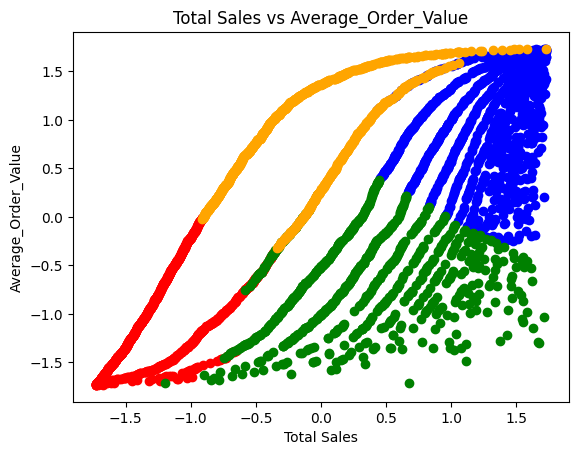

In [47]:
#Total Sales Vs Avg Order Value

plt.scatter(
    clustered_df.loc[clustered_df['Cluster'] == 0]['TotalSales'],
    clustered_df.loc[clustered_df['Cluster'] == 0]['Average_Order_Value'],
    c='blue'
)

plt.scatter(
    clustered_df.loc[clustered_df['Cluster'] == 1]['TotalSales'],
    clustered_df.loc[clustered_df['Cluster'] == 1]['Average_Order_Value'],
    c='red'
)

plt.scatter(
    clustered_df.loc[clustered_df['Cluster'] == 2]['TotalSales'],
    clustered_df.loc[clustered_df['Cluster'] == 2]['Average_Order_Value'],
    c='green'
)

plt.scatter(
    clustered_df.loc[clustered_df['Cluster'] == 3]['TotalSales'],
    clustered_df.loc[clustered_df['Cluster'] == 3]['Average_Order_Value'],
    c='orange'
)



plt.title('Total Sales vs Average_Order_Value')
plt.xlabel('Total Sales')
plt.ylabel('Average_Order_Value')

plt.show()

#In this graph, the blue group represents VIP customers with the highest sales and average order value, so the strategy is to retain them through exclusive rewards, premium services, and personalized engagement.
#The orange group shows strong spenders with medium to high sales and high order values; they can be upgraded to VIPs by encouraging repeat purchases with targeted promotions and memberships.
#The green group consists of frequent buyers who generate high sales but at lower average order values; bundle deals, upselling, and loyalty points can help increase their basket size. 
#Finally, the red group is the weakest segment with low sales and low order values, so discounts, free shipping thresholds, and awareness campaigns are needed to attract and convert them.

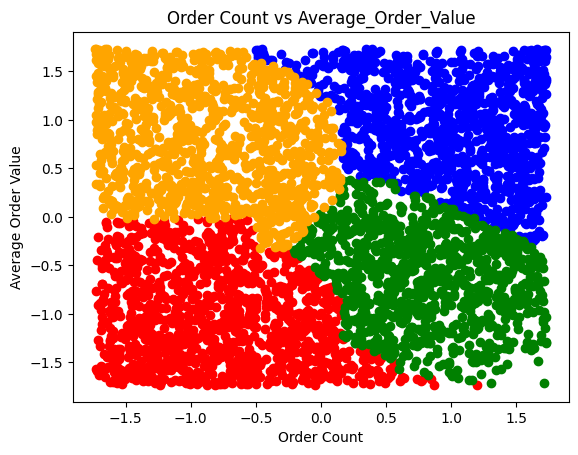

In [48]:
#Order Counts vs Average Order Value

plt.scatter(
    clustered_df.loc[clustered_df['Cluster'] == 0]['OrderCount'],
    clustered_df.loc[clustered_df['Cluster'] == 0]['Average_Order_Value'],
    c='blue'
)
plt.scatter(
    clustered_df.loc[clustered_df['Cluster'] == 1]['OrderCount'],
    clustered_df.loc[clustered_df['Cluster'] == 1]['Average_Order_Value'],
    c='red'
)
plt.scatter(
    clustered_df.loc[clustered_df['Cluster'] == 2]['OrderCount'],
    clustered_df.loc[clustered_df['Cluster'] == 2]['Average_Order_Value'],
    c='green'
)
plt.scatter(
    clustered_df.loc[clustered_df['Cluster'] == 3]['OrderCount'],
    clustered_df.loc[clustered_df['Cluster'] == 3]['Average_Order_Value'],
    c='orange'
)

plt.title('Order Count vs Average_Order_Value')
plt.xlabel('Order Count')
plt.ylabel('Average Order Value')

plt.show()

#In this graph, the blue cluster represents the most valuable customers, combining the highest order count with the highest average order value, so the focus should be on retaining them through premium loyalty programs, exclusive rewards, and personalized engagement. 
#The orange cluster shows occasional big spenders with low order frequency but high average order value; they can be encouraged to purchase more often with targeted campaigns and membership perks. 
#The green cluster consists of frequent buyers who place many orders but spend less per transaction, making them ideal candidates for bundle deals, upselling, and cross‑selling to grow basket size. 
#Finally, the red cluster is the weakest group with both low order count and low average order value, requiring entry‑level incentives such as discounts, free shipping thresholds, and awareness campaigns to convert them into more active customers.

In [49]:
#Part - 4

#Product Segmentation 

#Feature Scaling (ranking and normalizing the data)

product_df=df.groupby('StockCode').agg({
    'TotalSale':'sum',
    'Quantity':'sum',
    'InvoiceNo': 'nunique'
})

In [50]:
product_df.head()

,TotalSale,Quantity,InvoiceNo
StockCode,,,
10002,699.55,823,49
10080,114.41,291,21
10120,39.06,186,28
10123C,3.25,5,3
10124A,6.72,16,5


In [51]:
product_df.columns=['Total_Sales','Total_Quantity_Sold','Order_Count']
product_df

,Total_Sales,Total_Quantity_Sold,Order_Count
StockCode,,,
10002,699.550,823,49
10080,114.410,291,21
10120,39.060,186,28
10123C,3.250,5,3
10124A,6.720,16,5
...,...,...,...
C2,6536.000,131,130
DOT,10307.100,15,15
M,52981.830,6114,245


In [52]:
product_df['Average_Order_Quantity']=product_df['Total_Quantity_Sold']/product_df['Order_Count']
product_df

,Total_Sales,Total_Quantity_Sold,Order_Count,Average_Order_Quantity
StockCode,,,,
10002,699.550,823,49,16.795918
10080,114.410,291,21,13.857143
10120,39.060,186,28,6.642857
10123C,3.250,5,3,1.666667
10124A,6.720,16,5,3.200000
...,...,...,...,...
C2,6536.000,131,130,1.007692
DOT,10307.100,15,15,1.000000
M,52981.830,6114,245,24.955102


In [53]:
product_df.describe()

,Total_Sales,Total_Quantity_Sold,Order_Count,Average_Order_Quantity
count,3657.000000,3657.000000,3657.000000,3657.000000
mean,2288.766326,1330.386929,101.495215,11.514052
std,5769.849404,3153.949623,154.170529,28.016814
min,0.003000,1.000000,1.000000,1.000000
25%,122.030000,60.000000,11.000000,3.666667
50%,610.650000,370.000000,45.000000,7.285714
75%,1981.080000,1343.000000,128.000000,13.242105
max,137732.470000,77729.000000,1920.000000,1300.000000


In [54]:
ranked_df2=product_df.rank(method='first')

In [55]:
ranked_df2.describe()

,Total_Sales,Total_Quantity_Sold,Order_Count,Average_Order_Quantity
count,3657.000000,3657.000000,3657.000000,3657.000000
mean,1829.000000,1829.000000,1829.000000,1829.000000
std,1055.829295,1055.829295,1055.829295,1055.829295
min,1.000000,1.000000,1.000000,1.000000
25%,915.000000,915.000000,915.000000,915.000000
50%,1829.000000,1829.000000,1829.000000,1829.000000
75%,2743.000000,2743.000000,2743.000000,2743.000000
max,3657.000000,3657.000000,3657.000000,3657.000000


In [56]:
#normalize the data

normalized_df2 = (ranked_df2-ranked_df2.mean()) /ranked_df2.std()

In [57]:
normalized_df2.describe()

,Total_Sales,Total_Quantity_Sold,Order_Count,Average_Order_Quantity
count,3.657000e+03,3.657000e+03,3657.00000,3.657000e+03
mean,-3.108746e-17,3.108746e-17,0.00000,7.771865e-18
std,1.000000e+00,1.000000e+00,1.00000,1.000000e+00
min,-1.731340e+00,-1.731340e+00,-1.73134,-1.731340e+00
25%,-8.656702e-01,-8.656702e-01,-0.86567,-8.656702e-01
50%,0.000000e+00,0.000000e+00,0.00000,0.000000e+00
75%,8.656702e-01,8.656702e-01,0.86567,8.656702e-01
max,1.731340e+00,1.731340e+00,1.73134,1.731340e+00


In [58]:
#Finding the optimal number of clusters
for n_cluster in [2,3,4,5,6,7,8]:
    kmeans = KMeans(n_clusters=n_cluster).fit(
        normalized_df2[['Total_Sales','Total_Quantity_Sold','Order_Count', 'Average_Order_Quantity']]
    )
    silhouette_avg = silhouette_score(
        normalized_df2[['Total_Sales','Total_Quantity_Sold','Order_Count', 'Average_Order_Quantity']],
        kmeans.labels_
    )

    print('Silhouette Score for %i Clusters: %0.4f' % (n_cluster, silhouette_avg))
#The optimal number of clusters is 4.

Silhouette Score for 2 Clusters: 0.4786
Silhouette Score for 3 Clusters: 0.3822
Silhouette Score for 4 Clusters: 0.4090
Silhouette Score for 5 Clusters: 0.3739
Silhouette Score for 6 Clusters: 0.3698
Silhouette Score for 7 Clusters: 0.3520
Silhouette Score for 8 Clusters: 0.3356


In [59]:
#Finding the kmeans for the normalized data
kmeans2= KMeans(n_clusters=4).fit(
    normalized_df2[['Total_Sales','Total_Quantity_Sold','Order_Count', 'Average_Order_Quantity']])
clustered_df2= normalized_df2.copy(deep=True)

In [60]:
clustered_df2['Cluster']= kmeans2.labels_

In [61]:
clustered_df2

,Total_Sales,Total_Quantity_Sold,Order_Count,Average_Order_Quantity,Cluster
StockCode,,,,,
10002,0.114602,0.535124,0.059669,1.136547,3
10080,-0.889348,-0.153434,-0.559750,0.922498,3
10120,-1.264409,-0.376955,-0.372219,-0.124073,1
10123C,-1.683037,-1.550440,-1.444362,-1.533392,1
10124A,-1.629998,-1.253991,-1.265356,-0.996373,1
...,...,...,...,...,...
C2,1.437732,-0.549331,0.883666,-1.638522,2
DOT,1.568435,-1.254938,-0.726443,-1.640417,2
M,1.724711,1.573171,1.343020,1.450992,0


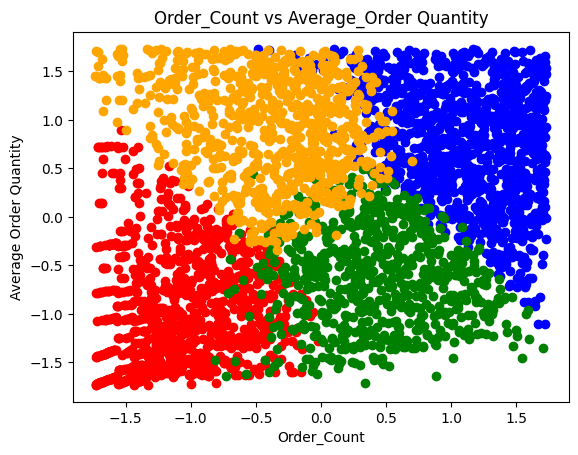

In [62]:
##Virtualize the data
#Order_count vs Average_Order_Quantity

plt.scatter(
    clustered_df2.loc[clustered_df2['Cluster']==0]['Order_Count'],
    clustered_df2.loc[clustered_df2['Cluster']==0]['Average_Order_Quantity'],
    c='blue'
)

plt.scatter(
    clustered_df2.loc[clustered_df2['Cluster']==1]['Order_Count'],
    clustered_df2.loc[clustered_df2['Cluster']==1]['Average_Order_Quantity'],
    c='red'
)

plt.scatter(
    clustered_df2.loc[clustered_df2['Cluster']==2]['Order_Count'],
    clustered_df2.loc[clustered_df2['Cluster']==2]['Average_Order_Quantity'],
    c='green'
)

plt.scatter(
    clustered_df2.loc[clustered_df2['Cluster']==3]['Order_Count'],
    clustered_df2.loc[clustered_df2['Cluster']==3]['Average_Order_Quantity'],
    c='orange'
)

plt.title('Order_Count vs Average_Order Quantity')
plt.xlabel('Order_Count')
plt.ylabel('Average Order Quantity')

plt.show()

#Green area (high orders + high avg quantity) → These are the VIP customers, highly engaged and high‑value. Strategy: retain them with premium loyalty programs, exclusive rewards, and personalized services.
#Blue area (low orders + high avg quantity) → These are occasional big spenders who buy rarely but in large amounts. Strategy: encourage frequency with targeted campaigns, reminders, and membership perks.
#Red area (low orders + low avg quantity) → These are low‑value customers, least engaged. Strategy: attract and convert them with discounts, free shipping thresholds, and awareness campaigns.
#Orange area (high orders + low avg quantity) → These are frequent small‑basket buyers. Strategy: grow their spend per order with bundle deals, upselling, and cross‑selling.

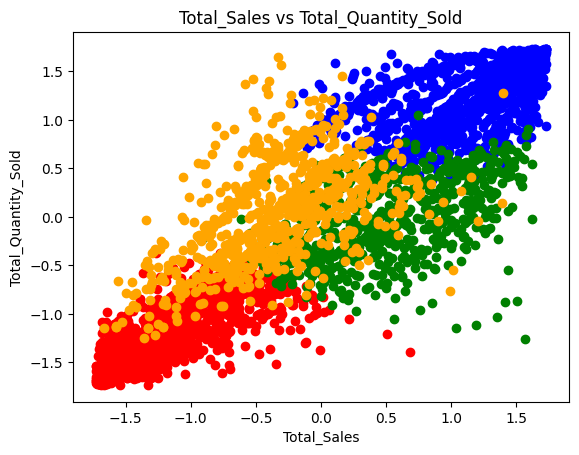

In [63]:
#Total_Sales vs Total_Quantity_Sold

plt.scatter(
    clustered_df2.loc[clustered_df2['Cluster']==0]['Total_Sales'],
    clustered_df2.loc[clustered_df2['Cluster']==0]['Total_Quantity_Sold'],
    c='blue'
)

plt.scatter(
    clustered_df2.loc[clustered_df2['Cluster']==1]['Total_Sales'],
    clustered_df2.loc[clustered_df2['Cluster']==1]['Total_Quantity_Sold'],
    c='red'
)

plt.scatter(
    clustered_df2.loc[clustered_df2['Cluster']==2]['Total_Sales'],
    clustered_df2.loc[clustered_df2['Cluster']==2]['Total_Quantity_Sold'],
    c='green'
)

plt.scatter(
    clustered_df2.loc[clustered_df2['Cluster']==3]['Total_Sales'],
    clustered_df2.loc[clustered_df2['Cluster']==3]['Total_Quantity_Sold'],
    c='orange'
)

plt.title('Total_Sales vs Total_Quantity_Sold')
plt.xlabel('Total_Sales')
plt.ylabel('Total_Quantity_Sold')

plt.show()

#In this graph, the green cluster represents the strongest customers with both high sales and high quantities, so the priority is to retain them through loyalty programs, exclusive rewards, and personalized engagement. 
#The orange cluster shows big‑ticket buyers who purchase fewer items but generate high sales; they should be encouraged to buy more often with targeted campaigns and memberships.
#The blue cluster reflects bulk buyers of low‑value items, making them ideal for upselling, cross‑selling, and bundle promotions to raise profitability.
#Finally, the red cluster is the weakest group with low sales and low quantities, requiring entry‑level incentives such as discounts, free shipping thresholds, and awareness campaigns to convert them into more active customers.

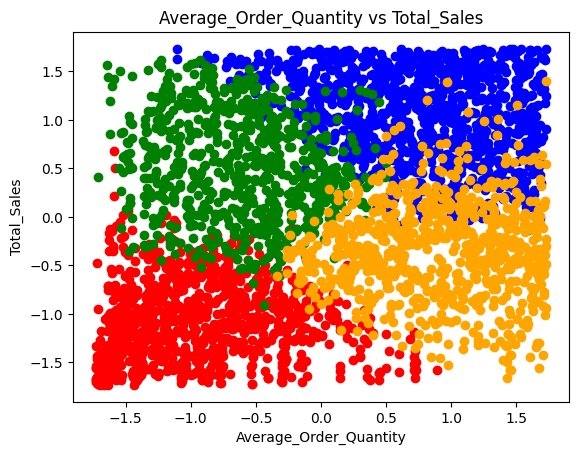

In [64]:
#Average_Order_Quantity vs Total_Sales

plt.scatter(
    clustered_df2.loc[clustered_df2['Cluster']==0]['Average_Order_Quantity'],
    clustered_df2.loc[clustered_df2['Cluster']==0]['Total_Sales'],
    c='blue'
)

plt.scatter(
    clustered_df2.loc[clustered_df2['Cluster']==1]['Average_Order_Quantity'],
    clustered_df2.loc[clustered_df2['Cluster']==1]['Total_Sales'],
    c='red'
)

plt.scatter(
    clustered_df2.loc[clustered_df2['Cluster']==2]['Average_Order_Quantity'],
    clustered_df2.loc[clustered_df2['Cluster']==2]['Total_Sales'],
    c='green'
)

plt.scatter(
    clustered_df2.loc[clustered_df2['Cluster']==3]['Average_Order_Quantity'],
    clustered_df2.loc[clustered_df2['Cluster']==3]['Total_Sales'],
    c='orange'
)

plt.title('Average_Order_Quantity vs Total_Sales')
plt.xlabel('Average_Order_Quantity')
plt.ylabel('Total_Sales')

plt.show()

#In this graph, the green cluster highlights the strongest customers with both high sales and high average order quantity, so the focus should be on retaining them through loyalty programs, exclusive rewards, and personalized engagement. 
#The blue cluster shows buyers with high to low in sales but smaller average order sizes; they can be encouraged to increase basket size with bundle deals and upselling. 
#The orange cluster represents occasional big spenders who buy rarely but in large amounts, so targeted campaigns and reminders can help boost their purchase frequency. 
#Finally, the red cluster is the weakest group with low sales and low average order quantity, requiring entry‑level incentives like discounts, free shipping thresholds, and awareness campaigns to convert them into more active customers.

In [65]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.
